In [24]:
import cv2
import os
import matplotlib.pyplot as plt

In [25]:
ROOT_DIR = "C:\\Adrianov\\Projects\\Project-Satanael\\"
DEMO_DIR = os.path.join(ROOT_DIR, 'attack_demo')
APRICOT_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Images', 'Test')
SEG_RES_DIR = os.path.join(ROOT_DIR, 'results_segment_grey')
MASK_RES_DIR = os.path.join(ROOT_DIR, 'results_mask')

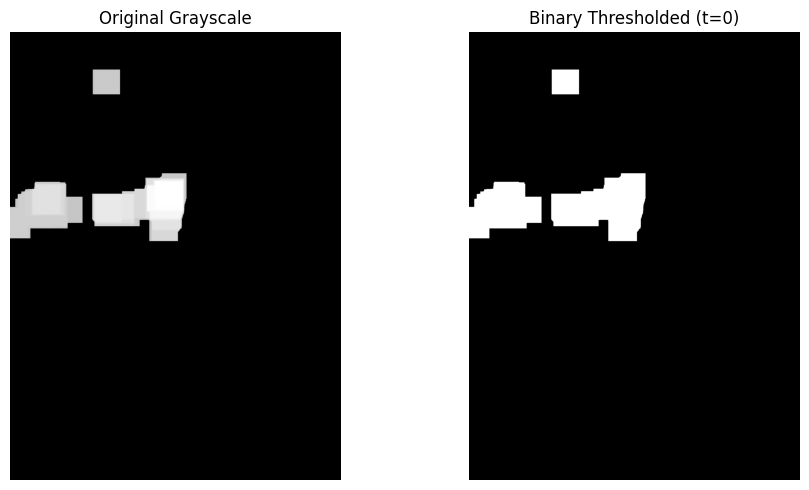

In [27]:
impath = os.path.join(SEG_RES_DIR, 'frc10_10.jpg_h_t_o_c_o.png')
img = cv2.imread(impath, cv2.IMREAD_GRAYSCALE)
_, binary_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Grayscale')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Binary Thresholded (t=0)')
plt.imshow(binary_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
os.makedirs(MASK_RES_DIR, exist_ok=True)
for filename in os.listdir(SEG_RES_DIR):
    if filename.lower().endswith(("_h_t_o_c_o.png")):
        input_path = os.path.join(SEG_RES_DIR, filename)
        
        # Read as grayscale
        img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Failed to read {input_path}")
            continue
        
        # Apply binary threshold with t = 0
        _, binary_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY)

        # Save the result
        output_path = os.path.join(MASK_RES_DIR, filename)
        cv2.imwrite(output_path, binary_img)
        print(f"Processed and saved: {output_path}")

Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_10.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_11.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_12.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_13.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_14.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_15.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_16.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_4.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_6.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_7.jpg_h_t_o_c_o.png
Processed and

In [31]:
MASKED_DIR = os.path.join(ROOT_DIR, 'masked')

# Ensure output directory exists
os.makedirs(MASKED_DIR, exist_ok=True)

for filename in os.listdir(APRICOT_TEST_DIR):
    if not filename.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    # Base name without extension
    name, ext = os.path.splitext(filename)

    # Expected mask filename
    mask_filename = name + ".jpg_h_t_o_c_o.png"
    mask_path = os.path.join(MASK_RES_DIR, mask_filename)

    if not os.path.exists(mask_path):
        print(f"Mask not found for {filename}, skipping.")
        continue

    # Load RGB image
    img_path = os.path.join(APRICOT_TEST_DIR, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to read image: {img_path}")
        continue

    # Load binary mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"Failed to read mask: {mask_path}")
        continue

    # Apply mask: keep only pixels where mask == 255
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # Save result
    output_path = os.path.join(MASKED_DIR, filename)
    cv2.imwrite(output_path, masked_img)
    print(f"Masked and saved: {output_path}")

Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_10.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_11.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_12.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_13.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_14.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_15.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_16.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_4.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_6.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_7.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_9.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc1_0.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc1_1.jpg
Masked and saved: C:

In [34]:
import os
import cv2
APRICOT_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Images', 'test_PAD')
MASK_RES_DIR = os.path.join(ROOT_DIR, 'results_mask')

def resize_all_masks():
    for fname in os.listdir(MASK_RES_DIR):
        if not fname.endswith('.png'):
            continue

        mask_path = os.path.join(MASK_RES_DIR, fname)

        # Extract base image name (e.g., 'frc1_3.jpg') from mask filename
        base_name = fname.split('_h_t_o_c_o')[0]
        original_path = os.path.join(APRICOT_TEST_DIR, base_name)

        # Load the original image to get its size
        original_img = cv2.imread(original_path)
        if original_img is None:
            print(f'[Warning] Original image not found: {original_path}')
            continue

        h, w = original_img.shape[:2]

        # Load the mask (grayscale)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f'[Warning] Could not load mask: {mask_path}')
            continue

        # Resize mask to match original image size
        resized_mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # Overwrite original mask with resized version
        cv2.imwrite(mask_path, resized_mask)
        print(f'[Info] Resized and saved: {fname}')


In [35]:
resize_all_masks()

[Info] Resized and saved: frc10_10.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_11.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_12.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_13.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_14.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_15.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_16.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_4.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_6.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_7.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_9.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_0.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_1.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_10.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_11.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_12.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_14.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_15.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_16.jpg_h_t_o_c_o.png
[Info] 

In [40]:
import os
import cv2
import numpy as np

OVERLAY_RES_DIR =  os.path.join(ROOT_DIR, 'results_overlay')

import cv2
import numpy as np
import json

def apply_mask_and_draw_boxes(annotation_path, target_category_id):
    os.makedirs(OVERLAY_RES_DIR, exist_ok=True)

    # Load COCO annotation file
    with open(annotation_path, 'r') as f:
        coco = json.load(f)

    # Build mappings
    from collections import defaultdict
    ann_by_image = defaultdict(list)
    for ann in coco['annotations']:
        ann_by_image[ann['image_id']].append(ann)

    filename_to_id = {img['file_name']: img['id'] for img in coco['images']}

    # Process each image
    for fname in os.listdir(APRICOT_TEST_DIR):
        if not fname.endswith('.jpg'):
            continue

        image_path = os.path.join(APRICOT_TEST_DIR, fname)
        mask_name = fname.replace('.jpg', '.jpg_h_t_o_c_o.png')
        mask_path = os.path.join(MASK_RES_DIR, mask_name)

        if not os.path.exists(mask_path):
            print(f'[Skip] No mask for {fname}')
            continue

        image_id = filename_to_id.get(fname)
        if image_id is None:
            print(f'[Skip] No image entry for {fname}')
            continue

        anns = [a for a in ann_by_image[image_id] if a['category_id'] == target_category_id]
        if not anns:
            print(f'[Skip] No annotations for category {target_category_id} in {fname}')
            continue

        # Load image and mask
        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            print(f'[Warning] Could not load image or mask for {fname}')
            continue

        if mask.shape != image.shape[:2]:
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Apply mask to image (keep only visible regions)
        masked_image = np.zeros_like(image)
        mask_binary = mask > 0
        masked_image[mask_binary] = image[mask_binary]

        # Draw bounding boxes from original image (regardless of mask)
        for ann in anns:
            x, y, w, h = ann['bbox']
            pt1 = (int(x), int(y))
            pt2 = (int(x + w), int(y + h))
            cv2.rectangle(masked_image, pt1, pt2, color=(0, 255, 0), thickness=2)

        # Save result
        save_path = os.path.join(OVERLAY_RES_DIR, fname)
        cv2.imwrite(save_path, masked_image)
        print(f'[Saved] {save_path}')


In [41]:
annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
apply_mask_and_draw_boxes(annot_path, 12)

[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_10.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_11.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_12.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_13.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_14.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_15.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_16.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_4.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_6.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_7.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_9.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc1_0.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc1_1.jpg
[Saved] C:\Adrianov\Projects\Proj

## Calculate Recall value of Segmentation

In [47]:
import json
import numpy as np
import cv2
import skimage.measure as skms


def get_regions_from_mask(mask, min_area=60):
    """Extract connected regions from a binary mask."""
    label = skms.label(mask)
    props = skms.regionprops(label)
    
    regions = []
    for i, prop in enumerate(props):
        if prop.area >= min_area:
            region_mask = (label == i + 1).astype(np.uint8)
            regions.append({
                'mask': region_mask,
                'bbox': prop.bbox,
                'area': prop.area
            })
    return regions

In [48]:
def calculate_iou(region_mask, bbox, epsilon=1e-8):
    """Compute IoU between a region mask and a COCO-style bbox, avoiding division by zero."""
    x1, y1, w, h = bbox
    x1, y1, x2, y2 = int(x1), int(y1), int(x1 + w), int(y1 + h)

    bbox_mask = np.zeros_like(region_mask, dtype=np.uint8)
    bbox_mask[y1:y2, x1:x2] = 1

    intersection = np.logical_and(region_mask, bbox_mask).sum()
    union = np.logical_or(region_mask, bbox_mask).sum()

    return intersection / (union + epsilon)

In [49]:
def match_region(region_mask, anns, threshold=0.5):
    """Check if region matches any annotation (IoU ≥ threshold)."""
    for ann in anns:
        iou = calculate_iou(region_mask, ann['bbox'])
        if iou >= threshold:
            return True
    return False



In [60]:
def tally_true_positive(
    coco_annotation_path, image_filename, category_id, mask, threshold=0.5
):
    """Given an image name and mask, return label (1/0) for each region in the mask."""

    with open(coco_annotation_path, 'r') as f:
        coco = json.load(f)

    image_id = None
    for img in coco['images']:
        if img['file_name'] == image_filename:
            image_id = img['id']
            break

    if image_id is None:
        raise ValueError(f"Image {image_filename} not found in COCO file.")

    anns = [
        ann for ann in coco['annotations']
        if ann['image_id'] == image_id and ann['category_id'] == category_id
    ]
    regions = get_regions_from_mask(mask)
    tp = 0
    fn = 0
    for ann in anns:
        for r in regions:
            if match_region(r['mask'], [ann], threshold):
                tp += 1
                continue
    if tp == 0:
        fn += 1
    return tp, fn

### Recall @IoU=0.5

In [61]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.5
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                        | 2/875 [00:00<05:14,  2.78it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|▉                                                                                        | 9/875 [00:07<11:07,  1.30it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▏                                                                                      | 12/875 [00:10<12:52,  1.12it/s]

...

Undetected adversarial patch @rrs9_9.jpg


Evaluating images:  67%|██████████████████████████████████████████████████████████▌                            | 589/875 [08:49<02:45,  1.73it/s]

Undetected adversarial patch @smc10_0.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 875/875 [08:55<00:00,  1.63it/s]

Undetected adversarial patch @smc10_3.jpg
Final recall score for segmentation method: 66.21848739495798%


### Recall @IOU=0.40

In [62]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.4
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                        | 2/875 [00:00<05:26,  2.67it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|▉                                                                                        | 9/875 [00:06<09:53,  1.46it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▏                                                                                      | 12/875 [00:08<11:19,  1.27it/s]

...

Undetected adversarial patch @rrs9_9.jpg


Evaluating images:  67%|██████████████████████████████████████████████████████████▌                            | 589/875 [08:16<03:00,  1.58it/s]

Undetected adversarial patch @smc10_0.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 875/875 [08:23<00:00,  1.74it/s]

Undetected adversarial patch @smc10_3.jpg
Final recall score for segmentation method: 71.42857142857143%


### Recall @IOU=0.35

In [63]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.35
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                        | 2/875 [00:00<04:46,  3.05it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|▉                                                                                        | 9/875 [00:06<09:01,  1.60it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▏                                                                                      | 12/875 [00:08<10:39,  1.35it/s]

...

Undetected adversarial patch @rrs9_9.jpg


Evaluating images:  67%|██████████████████████████████████████████████████████████▌                            | 589/875 [07:56<03:03,  1.56it/s]

Undetected adversarial patch @smc10_0.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 875/875 [08:02<00:00,  1.81it/s]

Undetected adversarial patch @smc10_3.jpg
Final recall score for segmentation method: 73.61344537815127%
